# Notebook 02m — PPO-CF on `MountainCar-v0`

Compare three arms from **one** config, differing in exactly one field,
`ppo.pg_mode`:

| arm | `pg_mode` | what it is |
|---|---|---|
| `gae` | `gae` | plain PPO — the control |
| `cf` | `cf_all_action` | PPO-CF with the rollout counterfactual estimator |
| `shuf` | `cf_shuffled` | the same oracle vectors on different states |

MountainCar is mainly a pipeline sanity check. The hard part is exploration: the
reward is `-1` until the goal is reached, so early one-step counterfactual
landscapes are nearly flat when the critic is still constant. This notebook uses
the online rollout estimator `Q_g`, but the result should still be read as a
sanity check before the MiniGrid experiments.


---
## Knobs


In [1]:
# ----------------------------------------------------------------------------
# EDIT ME
# ----------------------------------------------------------------------------
ENV_CONFIG    = "mountaincar_cf"
SEEDS         = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]       # None -> use the config's seeds
FORCE_RETRAIN = False

RUN_ORACLE_CHECKS = True
RUN_CONTROL       = True        # arm A: plain PPO
RUN_CF            = True        # arm B: PPO-CF
RUN_SHUFFLED      = False       # arm C: shuffled-oracle control

# Meaningful only after the baseline notebook has completed.
ORACLE_CHECK_RUN  = "nb01_baseline"
ORACLE_CHECK_CKPT = 0.75

OVERRIDES = {
    # "ppo.total_timesteps": 100_000,   # quick smoke run
    # "run.seeds": (0,),                # one seed while iterating
    # "ppo.cf_horizon": 16,             # cheaper, less rollout lookahead
    # "ppo.cf_subsample": 0.20,         # more labelled states, more cost
    # "ppo.alpha_cf": 0.1,              # smaller CF correction
    # "ppo.target_kl": 0.03,            # KL-match if CF steps are much larger
}
# ----------------------------------------------------------------------------


## 0. Setup


In [2]:
%load_ext autoreload
%autoreload 2

import sys, pathlib, time

ROOT = pathlib.Path.cwd()
if not (ROOT / "config").is_dir():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym

from config import make_config, seed_dir, RUNS_DIR, FIGURES_DIR
from dataio import load_trajectories, load_checkpoint, list_checkpoints
from utils.logging import read_scalars
from utils.plotting import savefig, plot_learning_curves
from scripts.train import run_seeds

base = make_config(ENV_CONFIG, **OVERRIDES)
if SEEDS is not None:
    base = make_config(ENV_CONFIG, **{**OVERRIDES, "run.seeds": tuple(SEEDS)})
SEEDS = tuple(base.run.seeds)
STEM = base.run.run_name

ARMS = {
    k: make_config(ENV_CONFIG, **{**OVERRIDES, "run.seeds": SEEDS,
                                  "ppo.pg_mode": m, "run.run_name": f"{STEM}_{k}"})
    for k, m in [("gae", "gae"), ("cf", "cf_all_action"), ("shuf", "cf_shuffled")]
}
FIG = FIGURES_DIR / f"nb02_{STEM}"
FIG.mkdir(parents=True, exist_ok=True)

ACTION_NAMES = ["push left", "no push", "push right"]

print(ARMS["cf"].summary())
print(f"arms: {[c.run.run_name for c in ARMS.values()]}   seeds: {list(SEEDS)}")

# Order-of-magnitude only; section 1 measures oracle throughput from this machine.
rate = {"gae": 1200, "cf": 180, "shuf": 180}
print("estimated runtime")
for k, c in ARMS.items():
    m = c.ppo.total_timesteps / rate[k] / 60
    print(f"  {k:4s} {m:5.1f} min/seed  x {len(SEEDS)} seeds = {m * len(SEEDS):5.1f} min")


config             mountaincar_cf
env                MountainCar-v0  (n_envs=16, obs_norm=fixed)
layouts            random every episode
total_timesteps    400,000  per seed
rollout batch      512  (16 envs x 32 steps)
updates            781
minibatch size     128  x 4 epochs
gamma / lambda     0.99 / 0.98
lr                 0.0007  (anneal=True)
encoder            mlp  (shared=False)
entropy            adaptive, coef 0.1
prob floor         0.0 -> 0.0  (0 = off)
adv norm           minibatch  (min_std 1e-06)
policy gradient    cf_all_action  alpha_gae=1.0 alpha_cf=0.5, Q_g horizon=32 x2 rollouts, subsample=10%, restore=exact
reward shaping     off
warm start         none
seeds              [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
checkpoints at     ['10%', '30%', '50%', '75%', '100%']
arms: ['mountaincar_gae', 'mountaincar_cf', 'mountaincar_shuf']   seeds: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
estimated runtime
  gae    5.6 min/seed  x 11 seeds =  61.1 min
  cf    37.0 min/seed  x 11 seeds = 407

---
# 1. Test The Oracle

For MountainCar the exact restore path is the right path. `cf_restore: fast` is
MiniGrid-only and is deliberately not tested here.


In [3]:
from envs.env_pool import set_sim_state, get_sim_state
from oracle.online import OnlineOracle, check_replay, check_centering, landscape_summary

if RUN_ORACLE_CHECKS:
    cfg = ARMS["cf"]
    K = 3
    sd = seed_dir(ORACLE_CHECK_RUN, SEEDS[0]) if ORACLE_CHECK_RUN else None
    traj_path = sd / "trajectories.npz" if sd else None
    if sd and traj_path.exists():
        traj = load_trajectories(traj_path)
        ckpts = list_checkpoints(sd / "checkpoints")
        if not ckpts:
            raise FileNotFoundError(f"no checkpoints found under {sd / 'checkpoints'}")
        loaded = [(p, load_checkpoint(p)) for p in ckpts]
        p_ck, ck = min(loaded, key=lambda pc: abs(pc[1].fraction - ORACLE_CHECK_CKPT))
        value_fn, probs_fn = ck.values, ck.probs
        src = f"{ORACLE_CHECK_RUN} @ {ck.fraction:.0%} ({p_ck.name})"
        N = min(600, len(traj))
        sims  = traj.sim_state[:N]
        acts  = traj.action[:N]
        rews  = traj.reward[:N]
        nsims = traj.next_sim_state[:N]
    else:
        from agents.ppo import PPOTrainer
        print(f"no completed trajectory at {traj_path}; using one live rollout for smoke-only oracle checks")
        _t = PPOTrainer(cfg, seed=SEEDS[0], progress=False)
        _t.pool.reset(); _t.collect_rollout()
        T, NE = cfg.ppo.n_steps, cfg.env.n_envs
        f = lambda a: a[:T].reshape((T * NE,) + a.shape[2:])
        sims, acts, rews, nsims = f(_t.buffer.sim_state), f(_t.buffer.actions), f(_t.buffer.rewards), f(_t.buffer.next_sim_state)
        value_fn, probs_fn = _t._values_np, _t._probs_np
        src = "fresh rollout"

    oracle = OnlineOracle(cfg.env.env_id, K, cfg.ppo.gamma, {},
                          cfg.env.max_episode_steps, restore=cfg.ppo.cf_restore)
    print(f"oracle check source: {src}; {len(sims)} states; K={K}")


oracle check source: nb01_baseline @ 75% (ckpt_075.pt); 600 states; K=3


## 1.1 Restore And Replay


In [4]:
if RUN_ORACLE_CHECKS:
    rep = check_replay(oracle, sims[:400], acts[:400], rews[:400], nsims[:400])
    print(f"  transitions replayed  {rep['n']}")
    print(f"  max reward error      {rep['max_reward_error']:.3e}")
    print(f"  max state error       {rep['max_state_error']:.3e}")
    print(f"  -> {'EXACT' if rep['exact'] else 'MISMATCH -- STOP, do not train'}")


  transitions replayed  400
  max reward error      0.000e+00
  max state error       0.000e+00
  -> EXACT


## 1.2 Centering And Landscape Shape


In [5]:
if RUN_ORACLE_CHECKS:
    obs0 = np.stack([set_sim_state(oracle.env, s, elapsed_steps=0) for s in sims[:300]])
    pi = probs_fn(obs0)
    a_cf, q_cf, diag = oracle.a_g(
        sims[:300], pi[:300], probs_fn, value_fn,
        horizon=cfg.ppo.cf_horizon, n_rollouts=cfg.ppo.cf_rollouts,
        bootstrap_tail=cfg.ppo.cf_bootstrap_tail, chunk=cfg.ppo.cf_branch_envs)
    c = check_centering(a_cf, pi[:300])
    s_ = landscape_summary(a_cf, q_cf, pi[:300], spread_threshold=cfg.oracle.spread_threshold)

    print("Q_g diagnostics")
    print(f"  branches that saw reward         {diag['reward_coverage']:.3f}")
    print(f"  branches terminating within H    {diag['terminated_within_horizon']:.3f}")
    print(f"  states with reward in some branch {diag['frac_states_any_reward']:.3f}")
    print()
    print("Landscape")
    print(f"  centering max |sum pi*A_CF|      {c['max_abs']:.3e}")
    print(f"  mean |A_CF|                      {s_['mean_abs_a_cf']:.4f}")
    print(f"  frac states with spread > {cfg.oracle.spread_threshold}    {s_['frac_states_with_spread']:.3f}")
    print(f"  all finite                       {s_['finite']}")
    print("  best action by A_CF:")
    for name, count in zip(ACTION_NAMES, s_["best_action_counts"]):
        print(f"    {name:10s} {count:5d}")


Q_g diagnostics
  branches that saw reward         1.000
  branches terminating within H    0.000
  states with reward in some branch 1.000

Landscape
  centering max |sum pi*A_CF|      1.352e-05
  mean |A_CF|                      0.0748
  frac states with spread > 0.01    0.797
  all finite                       True
  best action by A_CF:
    push left    234
    no push       32
    push right    34


## 1.3 Throughput


In [6]:
if RUN_ORACLE_CHECKS:
    batch = cfg.env.n_envs * cfg.ppo.n_steps
    probe = sims[:min(batch, len(sims))]
    t0 = time.time()
    oracle.q_g(probe, probs_fn, value_fn,
               horizon=cfg.ppo.cf_horizon, n_rollouts=cfg.ppo.cf_rollouts,
               bootstrap_tail=cfg.ppo.cf_bootstrap_tail, chunk=cfg.ppo.cf_branch_envs)
    dt = time.time() - t0
    sps = len(probe) / dt
    print(f"  exact restore Q_g throughput: {sps:.0f} collected states/s")
    print(f"  rough CF seed time at {cfg.ppo.total_timesteps:,} frames: {cfg.ppo.total_timesteps / max(sps, 1e-9) / 60:.1f} min")
    oracle.close()


  exact restore Q_g throughput: 701 collected states/s
  rough CF seed time at 400,000 frames: 9.5 min


## 1.4 Oracle Verdict


In [7]:
if RUN_ORACLE_CHECKS:
    checks = {
        "restore/replay is exact": rep["exact"],
        "A_CF is policy-centred (max < 1e-4)": c["ok"],
        "A_CF is finite": s_["finite"],
        f"actions differ in > {cfg.oracle.min_frac_states_with_spread:.0%} of states":
            s_["frac_states_with_spread"] > cfg.oracle.min_frac_states_with_spread,
    }
    width = max(len(k) for k in checks)
    for k, v in checks.items():
        print(f"  {'PASS' if v else 'FAIL'}  {k:<{width}}")
    print()
    print("ORACLE:", "PASS -- safe to train on" if all(checks.values())
          else "FAIL -- inspect before trusting CF results")


  PASS  restore/replay is exact            
  PASS  A_CF is policy-centred (max < 1e-4)
  PASS  A_CF is finite                     
  PASS  actions differ in > 20% of states  

ORACLE: PASS -- safe to train on


---
# 2. Train Arms


In [8]:
def train_arm(key):
    c = ARMS[key]
    done = all((seed_dir(c.run.run_name, s) / "scalars.csv").exists() for s in c.run.seeds)
    if done and not FORCE_RETRAIN:
        print(f"found existing run at {RUNS_DIR / c.run.run_name} -- skipping")
        return None
    t0 = time.time()
    out = run_seeds(c)
    print(f"{key}: {(time.time() - t0) / 60:.1f} min total")
    return out

if RUN_CONTROL:
    train_arm("gae")
if RUN_CF:
    train_arm("cf")
if RUN_SHUFFLED:
    train_arm("shuf")



=== seed 0 ====================================================
  upd    10/781  step    5,120  ret     nan  succ 0.00  sg1 nan sg2 nan  ent 1.097  advstd 5.79e+00  ev -0.098  13,881 sps
  upd    20/781  step   10,240  ret -500.000  succ 0.00  sg1 0.00 sg2 0.00  ent 1.096  advstd 5.03e+00  ev  0.063  13,795 sps
  upd    30/781  step   15,360  ret -500.000  succ 0.00  sg1 0.00 sg2 0.00  ent 1.098  advstd 4.76e+00  ev -0.010  15,856 sps
  upd    40/781  step   20,480  ret -500.000  succ 0.00  sg1 0.00 sg2 0.00  ent 1.096  advstd 4.37e+00  ev  0.018  17,170 sps
  upd    50/781  step   25,600  ret -500.000  succ 0.00  sg1 0.00 sg2 0.00  ent 1.085  advstd 4.09e+00  ev  0.000  18,098 sps
  upd    60/781  step   30,720  ret -500.000  succ 0.00  sg1 0.00 sg2 0.00  ent 0.913  advstd 3.83e+00  ev -0.020  18,641 sps
  upd    70/781  step   35,840  ret -500.000  succ 0.00  sg1 0.00 sg2 0.00  ent 0.706  advstd 3.50e+00  ev  0.022  19,155 sps
  upd    80/781  step   40,960  ret -500.000  succ 0.00 

---
# 3. Compare

The primary check is sample efficiency under training conditions, plus greedy
success at the standard 200-step evaluation limit.


In [9]:
scal = {k: {s: read_scalars(seed_dir(c.run.run_name, s) / "scalars.csv")
            for s in c.run.seeds if (seed_dir(c.run.run_name, s) / "scalars.csv").exists()}
        for k, c in ARMS.items()}
scal = {k: v for k, v in scal.items() if v}

THRESH = 0.9
def frames_to(d, col="success_rate_100", thresh=THRESH):
    hit = d.loc[d[col] >= thresh, "global_step"]
    return int(hit.iloc[0]) if len(hit) else None

rows = []
for arm, per_seed in scal.items():
    for s, d in per_seed.items():
        rows.append({
            "arm": arm,
            "seed": s,
            f"frames_to_{THRESH:g}": frames_to(d),
            "final_success": round(float(d["success_rate_100"].iloc[-1]), 3),
            "best_success": round(float(d["success_rate_100"].max()), 3),
            "ev_median": round(float(d["explained_variance"].median()), 3),
            "kl_median": round(float(d["approx_kl"].median()), 4),
            "clipfrac_median": round(float(d["clipfrac"].median()), 3),
            "cf_coverage": (round(float(d["cf_reward_coverage"].mean()), 3)
                            if "cf_reward_coverage" in d else None),
            "cf_corr_gae": (round(float(d["cf_corr_gae"].mean()), 3)
                            if "cf_corr_gae" in d else None),
        })
cmp_df = pd.DataFrame(rows).sort_values(["arm", "seed"])
display(cmp_df)

print(f"median frames to success >= {THRESH:g}")
for arm, g in cmp_df.groupby("arm"):
    v = g[f"frames_to_{THRESH:g}"].dropna()
    print(f"  {arm:4s} {('%.0f' % v.median()) if len(v) else 'never':>10s}   ({len(v)}/{len(g)} seeds reached it)")


,arm,seed,frames_to_0.9,final_success,best_success,ev_median,kl_median,clipfrac_median,cf_coverage,cf_corr_gae
11,cf,0,215040,1.00,1.00,0.600,0.0001,0.0,1.0,0.014
12,cf,1,194560,1.00,1.00,0.797,0.0001,0.0,1.0,0.054
13,cf,2,158720,1.00,1.00,0.891,0.0001,0.0,1.0,0.051
14,cf,3,87040,1.00,1.00,0.954,0.0002,0.0,1.0,0.054
15,cf,4,194560,1.00,1.00,0.764,0.0001,0.0,1.0,0.025
16,cf,5,322560,0.98,0.99,0.012,0.0001,0.0,1.0,0.056
17,cf,6,148480,1.00,1.00,0.901,0.0001,0.0,1.0,0.055
18,cf,7,194560,1.00,1.00,0.677,0.0001,0.0,1.0,0.058
19,cf,8,92160,1.00,1.00,0.969,0.0002,0.0,1.0,0.016
20,cf,9,209920,1.00,1.00,0.677,0.0001,0.0,1.0,0.028


median frames to success >= 0.9
  cf       194560   (11/11 seeds reached it)
  gae      204800   (11/11 seeds reached it)


## 3.1 Curves


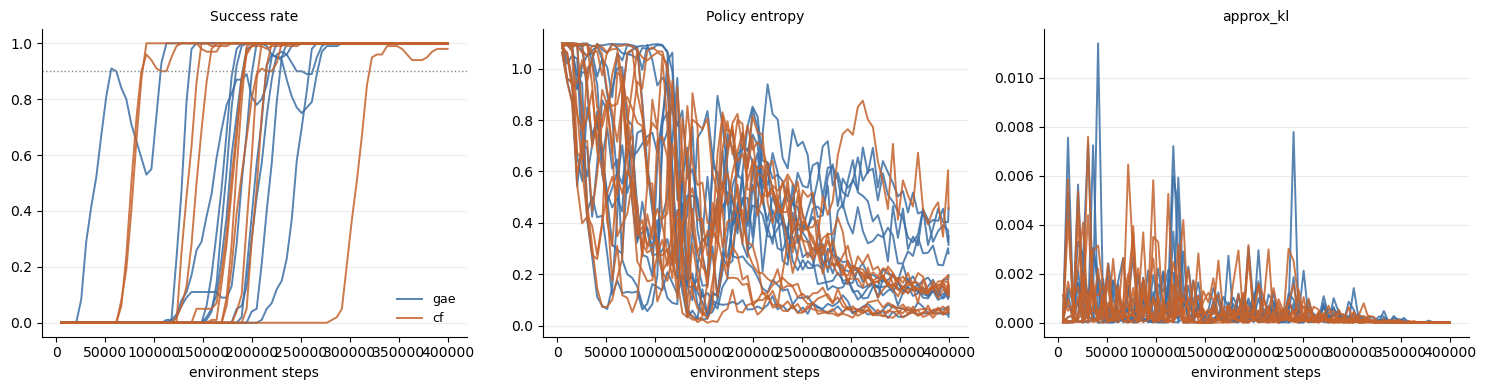

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = {"gae": "#3b6ea5", "cf": "#c4622d", "shuf": "#7a7a7a"}
panels = [("success_rate_100", "Success rate"),
          ("entropy", "Policy entropy"),
          ("approx_kl", "approx_kl")]
for ax, (col, title) in zip(axes, panels):
    for arm, per_seed in scal.items():
        for i, (s, d) in enumerate(per_seed.items()):
            if col not in d.columns:
                continue
            ax.plot(d["global_step"], d[col], lw=1.4, alpha=0.85, color=colors[arm],
                    label=arm if i == 0 else None)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("environment steps")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.25)
axes[0].axhline(THRESH, color="#888", ls=":", lw=1)
axes[0].set_ylim(-0.05, 1.05)
axes[0].legend(frameon=False, fontsize=9)
fig.tight_layout()
savefig(fig, FIG / "arms.png")
plt.show()


## 3.2 CF Health


In [11]:
for arm in ("cf", "shuf"):
    if arm not in scal:
        continue
    seed0 = sorted(scal[arm])[0]
    d = scal[arm][seed0]
    print()
    print(f"{ARMS[arm].run.run_name}  (seed {seed0})")
    checks = [
        ("cf_centering",       "max", "{:.3e}", "must stay near zero"),
        ("cf_reward_coverage", "last", "{:.3f}", "MountainCar reward is -1, so coverage should be high"),
        ("cf_corr_gae",        "mean", "{:+.3f}", "corr(A_CF taken, GAE)"),
        ("cf_mean_abs",        "mean", "{:.4f}", "|A_CF| in GAE-advantage units"),
        ("cf_n_cf_states",     "last", "{:.0f}", "states given a counterfactual per rollout"),
    ]
    for col, how, fmt, why in checks:
        if col not in d.columns or not np.isfinite(d[col]).any():
            print(f"  {col:20s} not logged")
            continue
        v = {"max": d[col].max(), "mean": d[col].mean(), "last": d[col].iloc[-1]}[how]
        print(f"  {col:20s} {how:>4} {fmt.format(v):>10}   {why}")



mountaincar_cf  (seed 0)
  cf_centering          max  5.974e-03   must stay near zero
  cf_reward_coverage   last      1.000   MountainCar reward is -1, so coverage should be high
  cf_corr_gae          mean     +0.014   corr(A_CF taken, GAE)
  cf_mean_abs          mean     0.1356   |A_CF| in GAE-advantage units
  cf_n_cf_states       last         51   states given a counterfactual per rollout


## 4. Reading The Result

If CF wins but `approx_kl` or `clipfrac` is much larger, rerun all arms with
`ppo.target_kl: 0.03` before attributing the win to counterfactual information.
If all arms overlap, MountainCar is doing its job as a pipeline check; move back
to the MiniGrid tasks for the main comparison.


In [12]:
for arm, per_seed in scal.items():
    print(f"\n===== {arm.upper()} =====")

    for seed, d in per_seed.items():
        print(f"\nSeed: {seed}")
        print(d.columns.tolist())
        break


===== GAE =====

Seed: 0
['update', 'global_step', 'lr', 'mean_return_100', 'mean_length_100', 'success_rate_100', 'subgoal1_rate_100', 'subgoal2_rate_100', 'n_episodes', 'entropy_target', 'success_ema', 'prob_floor', 'bonus_coef', 'eval_return', 'eval_success', 'sps', 'pg_loss', 'v_loss', 'entropy', 'approx_kl', 'clipfrac', 'grad_norm_critic', 'grad_norm_actor', 'explained_variance', 'early_stopped', 'ent_coef', 'adv_std_raw', 'cf_centering', 'cf_mean_abs', 'cf_corr_gae', 'cf_frac_states']

===== CF =====

Seed: 0
['update', 'global_step', 'lr', 'mean_return_100', 'mean_length_100', 'success_rate_100', 'subgoal1_rate_100', 'subgoal2_rate_100', 'n_episodes', 'entropy_target', 'success_ema', 'prob_floor', 'bonus_coef', 'eval_return', 'eval_success', 'sps', 'pg_loss', 'v_loss', 'entropy', 'approx_kl', 'clipfrac', 'grad_norm_critic', 'grad_norm_actor', 'explained_variance', 'early_stopped', 'ent_coef', 'adv_std_raw', 'cf_centering', 'cf_mean_abs', 'cf_corr_gae', 'cf_frac_states', 'cf_rew

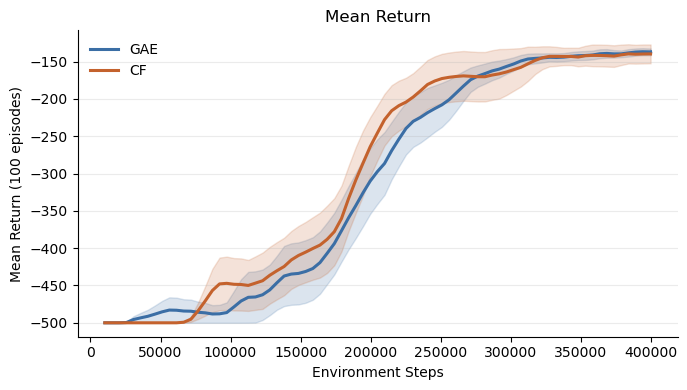

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

colors = {
    "gae": "#3b6ea5",
    "cf": "#c4622d",
}

fig, ax = plt.subplots(figsize=(7, 4))

for arm in ["gae", "cf"]:

    all_seeds = []

    for seed, d in scal[arm].items():
        temp = d[["global_step", "mean_return_100"]].copy()
        temp["seed"] = seed
        all_seeds.append(temp)

    # Combine all seeds
    combined = pd.concat(all_seeds, ignore_index=True)

    # Mean, standard deviation, and number of seeds
    stats = (
        combined
        .groupby("global_step")["mean_return_100"]
        .agg(["mean", "std", "count"])
        .reset_index()
    )

    # Standard error of the mean
    stats["sem"] = stats["std"] / np.sqrt(stats["count"])

    # Mean curve
    ax.plot(
        stats["global_step"],
        stats["mean"],
        lw=2.2,
        color=colors[arm],
        label=arm.upper()
    )

    # Mean ± SEM
    ax.fill_between(
        stats["global_step"],
        stats["mean"] - stats["sem"],
        stats["mean"] + stats["sem"],
        color=colors[arm],
        alpha=0.18
    )

ax.set_title("Mean Return")
ax.set_xlabel("Environment Steps")
ax.set_ylabel("Mean Return (100 episodes)")

ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.25)

ax.legend(frameon=False)

fig.tight_layout()

savefig(fig, FIG / "gae_cf_mean_return_sem.png")

plt.show()